In [8]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: False


## <font color='yellow'> FDR control on simulated data (uniform covariates X and simple responses Y)

In [9]:
import numpy as np
import pandas as pd 


def gen_data(setting, n, sig): 
    X = np.random.uniform(low=-1, high=1, size=n*20).reshape((n,20))
    
    if setting == 1: 
        # mu_x = (X[:,0] * X[:,1] > 0 ) * (X[:,3]>0.5) * (0.25+X[:,3]) + (X[:,0] * X[:,1] <= 0 ) * (X[:,3]<-0.5) * (X[:,3]-0.25)
        mu_x = (X[:,0] * X[:,1] > 0 ) * (X[:,3]*(X[:,3]>0.5) + 0.5*(X[:,3]<=0.5)) + (X[:,0] * X[:,1] <= 0 ) * (X[:,3]*(X[:,3]<-0.5) - 0.5*(X[:,3]>-0.5))
        mu_x = mu_x * 4
        Y = mu_x + np.random.normal(size=n) * sig
        # plt.scatter(mu_x, Y)
        return X, Y, mu_x
    
    if setting == 2:
        mu_x = (X[:,0] * X[:,1] + np.exp(X[:,3] - 1)) * 5
        Y = mu_x + np.random.normal(size=n) * 1.5 * sig 
        return X, Y, mu_x
    if setting == 3:
        mu_x = (X[:,0] * X[:,1] + np.exp(X[:,3] - 1)) * 5
        Y = mu_x + np.random.normal(size=n) * (5.5 - abs(mu_x))/2 * sig 
        return X, Y, mu_x
    
    if setting == 4:
        mu_x = (X[:,0] * X[:,1] + np.exp(X[:,3] - 1)) * 5
        sig_x = 0.25 * mu_x**2 * (np.abs(mu_x) < 2) + 0.5 * np.abs(mu_x) * (np.abs(mu_x) >= 1)
        Y = mu_x + np.random.normal(size=n) * sig_x * sig
        return X, Y, mu_x
    
    if setting == 5:
        mu_x = (X[:,0] * X[:,1] > 0 ) * (X[:,3]>0.5) * (0.25+X[:,3]) + (X[:,0] * X[:,1] <= 0 ) * (X[:,3]<-0.5) * (X[:,3]-0.25)
        mu_x = mu_x  
        Y = mu_x + np.random.normal(size=n) * sig
        return X, Y, mu_x
    
    if setting == 6:
        mu_x = (X[:,0] * X[:,1] + X[:,2]**2 + np.exp(X[:,3] - 1) - 1) * 2
        Y = mu_x + np.random.normal(size=n) * 1.5 * sig 
        return X, Y, mu_x
    
    if setting == 7:
        mu_x = (X[:,0] * X[:,1] + X[:,2]**2 + np.exp(X[:,3] - 1) - 1) * 2
        Y = mu_x + np.random.normal(size=n) * (5.5 - abs(mu_x))/2 * sig 
        return X, Y, mu_x
    
    if setting == 8:
        mu_x = (X[:,0] * X[:,1] + X[:,2]**2 + np.exp(X[:,3] - 1) - 1) * 2
        sig_x = 0.25 * mu_x**2 * (np.abs(mu_x) < 2) + 0.5 * np.abs(mu_x) * (np.abs(mu_x) >= 1)
        Y = mu_x + np.random.normal(size=n) * sig_x * sig
        return X, Y, mu_x
     
 

def BH(calib_scores, test_scores, q = 0.1):
    ntest = len(test_scores)
    ncalib = len(calib_scores)
    pvals = np.zeros(ntest)
    
    for j in range(ntest):
        pvals[j] = (np.sum(calib_scores < test_scores[j]) + np.random.uniform(size=1)[0] * (np.sum(calib_scores == test_scores[j]) + 1)) / (ncalib+1)
         
    
    # BH(q) 
    df_test = pd.DataFrame({"id": range(ntest), "pval": pvals}).sort_values(by='pval')
    
    df_test['threshold'] = q * np.linspace(1, ntest, num=ntest) / ntest 
    idx_smaller = [j for j in range(ntest) if df_test.iloc[j,1] <= df_test.iloc[j,2]]
    
    if len(idx_smaller) == 0:
        return(np.array([]))
    else:
        idx_sel = np.array(df_test.index[range(np.max(idx_smaller)+1)])
        return(idx_sel)
    

In [10]:
import numpy as np
import pandas as pd 
import random
import sys
import os
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


sig_id = 1
nt_id = 1
set_id = 1  
q = 0.1 
seed = 42
    
    
n = 1000
ntests = [10, 100, 500, 1000]
ntest = ntests[nt_id]
sig_seq = np.linspace(0.1, 1, num = 10)
sig = sig_seq[sig_id]
reg_names = ['gbr', 'rf', 'svm']
 
all_res = pd.DataFrame()

out_dir = "../conformal_results/"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
    print("Output diretory created!")
    
random.seed(seed)


for reg_method in range(3):
    reg_method = reg_method + 1
    reg_name = reg_names[reg_method - 1] 
    
    Xtrain, Ytrain, mu_train = gen_data(set_id, n, sig)
    Xcalib, Ycalib, mu_calib = gen_data(set_id, n, sig)
    
    Xtest, Ytest, mu_test = gen_data(set_id, ntest, sig)
    
    # training the prediction model
    if reg_method == 1:
        regressor = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=0)
    if reg_method == 2:
        regressor = RandomForestRegressor(max_depth=5, random_state=0)
    if reg_method == 3:
        regressor = SVR(kernel="rbf", gamma=0.1)
    
    regressor.fit(Xtrain, 1*(Ytrain>0))
    
    # calibration 
    calib_scores = Ycalib - regressor.predict(Xcalib) 
    calib_scores0 = - regressor.predict(Xcalib) 
    calib_scores_clip = Ycalib * (Ycalib > 0) - regressor.predict(Xcalib)
    calib_scores_2clip = 1000 * (Ycalib > 0) - regressor.predict(Xcalib)
     
    test_scores = - regressor.predict(Xtest) 
    
    # BH using residuals
    BH_res= BH(calib_scores, test_scores, q )
    # summarize
    if len(BH_res) == 0:
        BH_res_fdp = 0
        BH_res_power = 0
    else:
        BH_res_fdp = np.sum(Ytest[BH_res] < 0) / len(BH_res)
        BH_res_power = np.sum(Ytest[BH_res] >= 0) / sum(Ytest >= 0)
        
    
    # only use relevant samples to calibrate
    BH_rel = BH(calib_scores0[Ycalib <= 0], test_scores, q )
    if len(BH_rel) == 0:
        BH_rel_fdp = 0
        BH_rel_power = 0
    else:
        BH_rel_fdp = np.sum(Ytest[BH_rel] < 0) / len(BH_rel)
        BH_rel_power = np.sum(Ytest[BH_rel] >= 0) / sum(Ytest >= 0)
    
        
    # use clipped scores
    BH_2clip = BH(calib_scores_2clip, test_scores, q )
    if len(BH_2clip) == 0:
        BH_2clip_fdp = 0
        BH_2clip_power = 0
    else:
        BH_2clip_fdp = np.sum(Ytest[BH_2clip] < 0) / len(BH_2clip)
        BH_2clip_power = np.sum(Ytest[BH_2clip] >= 0) / sum(Ytest >= 0)
    

    all_res = pd.concat((all_res, 
                         pd.DataFrame({'BH_res_fdp': [BH_res_fdp], 
                                       'BH_res_power': [BH_res_power],
                                       'BH_res_nsel': [len(BH_res)],
                                       'BH_rel_fdp': [BH_rel_fdp], 
                                       'BH_rel_power': [BH_rel_power], 
                                       'BH_rel_nsel': [len(BH_rel)], 
                                       'BH_2clip_fdp': [BH_2clip_fdp], 
                                       'BH_2clip_power': [BH_2clip_power], 
                                       'BH_2clip_nsel': [len(BH_2clip)],
                                       'q': [q], 'regressor': [reg_name],
                                       'seed': [seed], 'sigma': [sig], 'ntest': [ntest]})))


all_res.to_csv("../conformal_results/prob_set"+str(set_id)+"q"+str(int(q*10))+"sig"+str(sig_id)+"nt"+str(nt_id)+"seed"+str(seed)+".csv")

Output diretory created!


results reproduced just fine, with working algorithm on simulated dataset :)

## <font color='yellow'> CIFAR data

In [11]:
ds = pickle.load(open('sgp_set_cnn','rb'))

In [12]:
ds['kappa'].loc[ds.y_pred == 0] = 1-ds.loc[ds.y_pred == 0].kappa

In [13]:
ds.rename({'kappa':'class_1_proba'},axis=1,inplace=True)

In [14]:
from sklearn.model_selection import train_test_split
ds_train, ds_test = train_test_split(ds, test_size=0.5, shuffle=True, random_state=0)

In [15]:
ds_train

,y_true,y_pred,class_1_proba
12812,0.0,0.0,0.224329
33842,0.0,0.0,0.371783
27705,0.0,0.0,0.229385
37740,0.0,0.0,0.406270
20217,0.0,0.0,0.365182
...,...,...,...
20757,0.0,1.0,0.635777
32103,0.0,0.0,0.168094
30403,0.0,0.0,0.078758
21243,0.0,0.0,0.115014


In [16]:
ds_train['V'] = ds_train.y_true - ds_train.class_1_proba

In [17]:
ds_test['V'] = 0.5 - ds_test.class_1_proba # the more the model predicts 0, the less conform to class 1 => higher non-conformity score V

In [18]:
ds_train

,y_true,y_pred,class_1_proba,V
12812,0.0,0.0,0.224329,-0.224329
33842,0.0,0.0,0.371783,-0.371783
27705,0.0,0.0,0.229385,-0.229385
37740,0.0,0.0,0.406270,-0.406270
20217,0.0,0.0,0.365182,-0.365182
...,...,...,...,...
20757,0.0,1.0,0.635777,-0.635777
32103,0.0,0.0,0.168094,-0.168094
30403,0.0,0.0,0.078758,-0.078758
21243,0.0,0.0,0.115014,-0.115014


In [19]:
p_values = []
for j in range(ds_test.shape[0]):
    U_j = rd.uniform(0,1)
    V_hat = ds_test.iloc[[j]].V.item()
    S1 = (ds_train.V < V_hat).sum()
    S2 = (ds_train.V == V_hat).sum()
    p_j = (S1+(1+S2)*U_j)/(ds_train.shape[0]+1)
    p_values.append(p_j)

In [20]:
p_values = np.array(p_values)

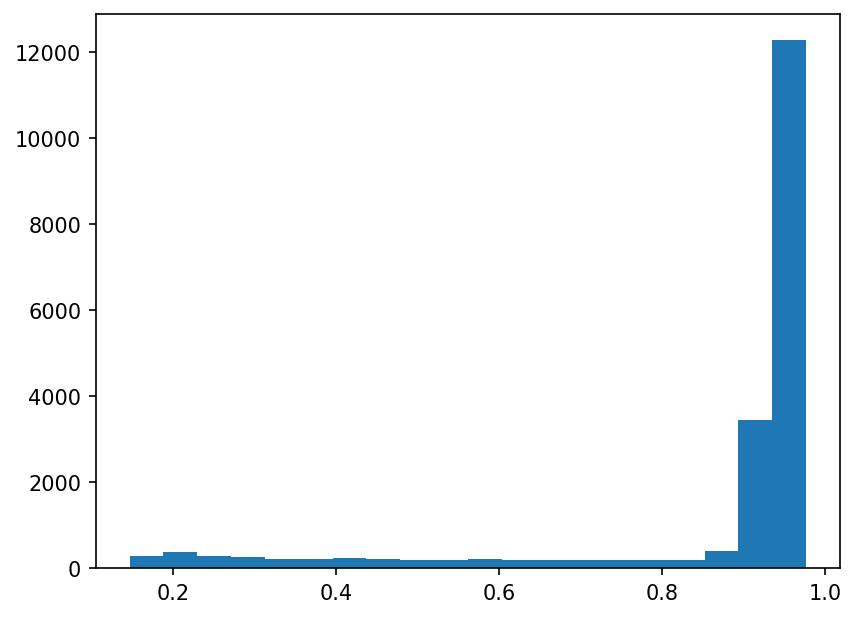

In [21]:
plt.hist(p_values, bins=20)
plt.show()

### cfBH algorithm

In [22]:
q = 0.1

k = 1
S = (p_values <= q*k/ds_test.shape[0]).sum()
while S/k >= 1:
    k += 1
    S = (p_values <= q*k/ds_test.shape[0]).sum()
k_star = k-1

In [23]:
k_star # selection set is empty

0

Detail on why cfBH returns empty selection set:

In [24]:
k=1
# p-value selected if below:
q*k/ds_test.shape[0]

5e-06

In [25]:
min(p_values) 

np.float64(0.14674555884738846)

__Conclusion__ 

=> the cfBH algorithm is too conservative to yield results on CIFAR classification task

In (Jin & Candès, 2023), the numerical experiments from the paper are based on simulated datasets with iid covariates drawn with simple $\mathcal{U}([-1,1])$ distributions.